# LSTM Auto-encoder (The sequence detection machine)

## It detects a sequence in the temporal pattern of what a normal array of days looks like. Then it tries to recreate those days in a similar fashion. If the pattern it created deviates from the original data, that is the "anomaly" I'm looking for. 

Some issue with this model and my data structure is that so far I have been using flat matrix of data, which is completely fine for statistics and isolation forest but does not work well here. It requres all the share data + the 5 features I created. Which isn't present in a single table so far. 

So first I must re-organize all the data points for this model to learn "What a normal might be?"

## Choice of data 

. To learn from: 2015-2019 data (Considered calmer economically)
. Testing data: 2015-2025 data (To compare with all the other models)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

DATA_DIR = Path("../data")
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")

feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]
print("Loaded:", features.shape)
print("CUDA available:", torch.cuda.is_available())
features[feature_cols].head()

Loaded: (1184191, 5)
CUDA available: True


ret_zscore     vol_5    vol_20    vol_60  vol_zscore
Date       Ticker                                                      
2015-03-31 A        -0.265173  0.010081  0.012668  0.014717   -0.410469
           AAPL     -0.938536  0.020079  0.014414  0.017461   -0.650943
           ABBV      0.313154  0.015403  0.019325  0.020973   -0.017244
           ABT      -1.348182  0.009937  0.011308  0.011799    0.387669
           ACGL     -2.030660  0.011328  0.009421  0.008541    2.016447

In [2]:

def make_sequences(stock_features, window=30):
    """
    stock_features: 2D array (days, 5 features) for ONE stock, in date order
    Returns: 3D array (num_sequences, window, 5)
             each sequence is `window` consecutive days of features
    """
    sequences = []
    for i in range(len(stock_features) - window + 1):
        seq = stock_features[i : i + window]   # days i to i+window-1
        sequences.append(seq)
    return np.array(sequences)

## First testing it on a small sample of Apple 

In [3]:
feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]

aapl = features.xs("AAPL", level="Ticker").sort_index()
aapl_arr = aapl[feature_cols].values
print("AAPL feature array shape:", aapl_arr.shape)

aapl_seqs = make_sequences(aapl_arr, window=30)
print("AAPL sequences shape:", aapl_seqs.shape)

AAPL feature array shape: (2456, 5)
AAPL sequences shape: (2427, 30, 5)


## Since it was able to work on 1 stock. I'll run all 499 stocks. 

I cannot just import all the stocks and run this 2D to 3D data conversion as that would combine different stocks together tainting the data. I have to stack each ticker on top of one another and then under each ticker the data can be stored by date and their respective features. 

In [4]:
all_sequences = []
sequence_index = []   # track which (date, ticker) each sequence ENDS on

for ticker in features.index.get_level_values("Ticker").unique():
    stock = features.xs(ticker, level="Ticker").sort_index()
    arr = stock[feature_cols].values
    if len(arr) < 30:          # too short to form even one sequence
        continue
    seqs = make_sequences(arr, window=30)
    all_sequences.append(seqs)
    # the endpoint date of each sequence (day 30 onward)
    sequence_index.extend(
        [(d, ticker) for d in stock.index[29:]]
    )

X_seq = np.concatenate(all_sequences, axis=0)
print("Full sequence array shape:", X_seq.shape)
print("Index entries:", len(sequence_index))

Full sequence array shape: (1169720, 30, 5)
Index entries: 1169720


# Now splitting the data into learning and testing structures (PS testing structure is done)

In [6]:
seq_dates = pd.to_datetime([d for (d, t) in sequence_index])

train_mask = (seq_dates >= pd.Timestamp("2015-01-01")) & (seq_dates <= pd.Timestamp("2019-12-31"))

X_train = X_seq[train_mask]
print("Training sequences (2015-2019):", X_train.shape)
print("Total sequences (score everything):", X_seq.shape)

Training sequences (2015-2019): (550594, 30, 5)
Total sequences (score everything): (1169720, 30, 5)


## Identifying the NaNs because the model cannot learn from NaNs and will choke on them. 

In [7]:
print("NaNs in training data:", np.isnan(X_train).sum())
print("NaNs in full data:", np.isnan(X_seq).sum())

NaNs in training data: 0
NaNs in full data: 0


## Perfect, everything is ready to run now. 

# The LSTM Autoencoder:

## First the autoencoder: It basically learns to compress and decompress the data. 

In [8]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=5, hidden_size=32, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size

        # ENCODER: reads the 30-day sequence, compresses to one hidden vector
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)

        # DECODER: expands the hidden vector back into a 30-day sequence
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # x shape: (batch, 30, 5)
        _, (hidden, _) = self.encoder(x)          # encode → final hidden state
        # repeat that hidden vector 30 times, one per timestep to reconstruct
        latent = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder(latent)          # decode → 30-day sequence
        reconstruction = self.output_layer(decoded)  # map back to 5 features
        return reconstruction

model = LSTMAutoencoder().to(device)
print(model)
print("Device:", device)

LSTMAutoencoder(
  (encoder): LSTM(5, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=5, bias=True)
)
Device: cuda


## It's using GPU to learn which makes it faster. It encoded everything and decoded all 32 batches. 

> Good to proceed

## Next we set up the machine. Setting the parameters and how the data will be fed. 

> It will be fed in small batches so it does not overwhelm my GPU. 
> Next it measures loses for data during reconstruction and optimizer tinkers with the weights so each repetition of reconstruction creates lesser data losses
> lr = 1e-3 is the standard weight adjusting parameter

In [9]:
# Convert training data to a PyTorch tensor on the GPU
X_train_t = torch.tensor(X_train, dtype=torch.float32)

# DataLoader feeds data in batches rather than all 550k at once
from torch.utils.data import DataLoader, TensorDataset
train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=256,
    shuffle=True,
)

loss_fn = nn.MSELoss()                                  # how we measure reconstruction error
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # how we adjust weights

## Running 10 loops for data to compress and reconstruct each iteration showing the missing data value:

In [10]:
n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)

        reconstruction = model(batch)        # 1. forward: reconstruct the batch
        loss = loss_fn(reconstruction, batch)  # 2. measure how wrong it was

        optimizer.zero_grad()                # 3. clear old gradients
        loss.backward()                      # 4. compute how to adjust each weight
        optimizer.step()                     # 5. nudge weights toward less-wrong

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs}  —  avg reconstruction loss: {avg_loss:.6f}")

Epoch 1/10  —  avg reconstruction loss: 0.315871
Epoch 2/10  —  avg reconstruction loss: 0.271624
Epoch 3/10  —  avg reconstruction loss: 0.257254
Epoch 4/10  —  avg reconstruction loss: 0.244453
Epoch 5/10  —  avg reconstruction loss: 0.233844
Epoch 6/10  —  avg reconstruction loss: 0.225488
Epoch 7/10  —  avg reconstruction loss: 0.219530
Epoch 8/10  —  avg reconstruction loss: 0.212496
Epoch 9/10  —  avg reconstruction loss: 0.206103
Epoch 10/10  —  avg reconstruction loss: 0.199663


## As we can see, the data loss is clearly converging towards a lower point. This shows a healthy data reconstruction rate. Now I can keep running these untin Epoch = N {N > 10} but the returns in losses aren't massive. So it would just be trading off my time for a very small return. This is where I stop, for future comparision I might go for a much lesser losses to have a much defined trained model. 

For now, this shows a clear trend of reconstruction that I am content with. 

# Running it for all the data points: 

## 

In [ ]:
model.eval()   # switch to evaluation mode (turns off training-only behaviors)

X_all_t = torch.tensor(X_seq, dtype=torch.float32)
all_loader = DataLoader(TensorDataset(X_all_t), batch_size=256, shuffle=False)

recon_errors = []
with torch.no_grad():                      # no gradient tracking → faster, less memory
    for (batch,) in all_loader:
        batch = batch.to(device)
        reconstruction = model(batch)
        # per-sequence error: average squared diff across all 30×5 values in each sequence
        err = ((reconstruction - batch) ** 2).mean(dim=(1, 2))
        recon_errors.extend(err.cpu().numpy())
        
recon_errors = np.array(recon_errors)
print("Reconstruction errors computed:", recon_errors.shape)
print("Should match sequence count:", X_seq.shape[0])

Reconstruction errors computed: (1169720,)
Should match sequence count: 1169720


In [12]:
print("Min error:   ", recon_errors.min())
print("Median error:", np.median(recon_errors))
print("Mean error:  ", recon_errors.mean())
print("Max error:   ", recon_errors.max())
print("99th pctile: ", np.percentile(recon_errors, 99))

Min error:    0.02374917
Median error: 0.1951775
Mean error:   0.19852388
Max error:    0.54840285
99th pctile:  0.3398534


In [13]:
torch.save(model.state_dict(), DATA_DIR / "lstm_autoencoder.pth")
np.save(DATA_DIR / "lstm_recon_errors.npy", recon_errors)
print("Saved model and errors.")

Saved model and errors.


# Bringing back the trained sequence back 

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

DATA_DIR = Path("../data")
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")
feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loaded:", features.shape, "| device:", device)

Loaded: (1184191, 5) | device: cuda


In [2]:
def make_sequences(stock_features, window=30):
    sequences = []
    for i in range(len(stock_features) - window + 1):
        sequences.append(stock_features[i : i + window])
    return np.array(sequences)

all_sequences = []
sequence_index = []
for ticker in features.index.get_level_values("Ticker").unique():
    stock = features.xs(ticker, level="Ticker").sort_index()
    arr = stock[feature_cols].values
    if len(arr) < 30:
        continue
    seqs = make_sequences(arr, window=30)
    all_sequences.append(seqs)
    sequence_index.extend([(d, ticker) for d in stock.index[29:]])

X_seq = np.concatenate(all_sequences, axis=0)
print("Sequences:", X_seq.shape, "| index entries:", len(sequence_index))

Sequences: (1169720, 30, 5) | index entries: 1169720


In [3]:
recon_errors = np.load(DATA_DIR / "lstm_recon_errors.npy")
print("Errors reloaded:", recon_errors.shape, "| should match:", X_seq.shape[0])

Errors reloaded: (1169720,) | should match: 1169720


## Checking if the result is fair or if there is a fault in the model

In [4]:
lstm_results = pd.DataFrame(
    {"recon_error": recon_errors},
    index=pd.MultiIndex.from_tuples(sequence_index, names=["Date", "Ticker"])
)
check = features.join(lstm_results, how="inner")

top = check.nlargest(5000, "recon_error")
print("HIGH-error days — mean absolute features:")
print(top[feature_cols].abs().mean())
print("\nOVERALL — mean absolute features:")
print(check[feature_cols].abs().mean())

HIGH-error days — mean absolute features:
ret_zscore    0.689320
vol_5         0.051782
vol_20        0.052166
vol_60        0.033716
vol_zscore    0.823627
dtype: float64

OVERALL — mean absolute features:
ret_zscore    0.756648
vol_5         0.016392
vol_20        0.017754
vol_60        0.018398
vol_zscore    0.829388
dtype: float64


## is the model actually reconstructing the input at all, or outputting mush?

In [6]:
import torch.nn as nn

# Step 1: recreate the architecture (must match exactly what you trained)
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=5, hidden_size=32, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        latent = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder(latent)
        return self.output_layer(decoded)

# Step 2: build empty model, load saved weights into it
model = LSTMAutoencoder().to(device)
model.load_state_dict(torch.load(DATA_DIR / "lstm_autoencoder.pth"))
model.eval()
print("Model reloaded and ready.")

Model reloaded and ready.


In [7]:
# grab one batch, compare a real trajectory to its reconstruction
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_seq[:1], dtype=torch.float32).to(device)
    recon = model(sample).cpu().numpy()

print("Original first 3 days:\n", X_seq[0][:3])
print("\nReconstructed first 3 days:\n", recon[0][:3])

Original first 3 days:
 [[-0.26517311  0.01008144  0.01266753  0.0147168  -0.41046906]
 [-0.25738397  0.00944323  0.01262566  0.01450799  0.25862453]
 [ 1.21394061  0.01010367  0.0130968   0.01447494  0.15668954]]

Reconstructed first 3 days:
 [[0.1887731  0.01506779 0.01530151 0.01543429 0.10732724]
 [0.26902628 0.01518089 0.01492865 0.01508451 0.20411226]
 [0.36461473 0.01575461 0.01496659 0.0150064  0.31845897]]


## My findings:

> For the first 3 days, the volume and volatility are decently tracked. It follows the trajectory and even nails some of the values while reconstructing. 

> for ret_zscores values, it averages very loosely. (For eg: The 3rd day ret_zscore value original: 1.21, and reconstructed: 0.36 thats a 3.3x value difference.)

## This clearly shows that my model is undertrained. I will have to retrain with much more instances this time to get it right. 

## Re-establishing the architect to train the data set again. With a clean slate. 

In [8]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=5, hidden_size=64, seq_len=30):   # 32 → 64
        super().__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        latent = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder(latent)
        return self.output_layer(decoded)

model = LSTMAutoencoder(hidden_size=64).to(device)
print(model)

LSTMAutoencoder(
  (encoder): LSTM(5, 64, batch_first=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=5, bias=True)
)


In [10]:
seq_dates = pd.to_datetime([d for (d, t) in sequence_index])

train_mask = (seq_dates >= pd.Timestamp("2015-01-01")) & (seq_dates <= pd.Timestamp("2019-12-31"))

X_train = X_seq[train_mask]
print("Training sequences (2015-2019):", X_train.shape)

Training sequences (2015-2019): (550594, 30, 5)


In [11]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 40
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        reconstruction = model(batch)
        loss = loss_fn(reconstruction, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    if (epoch + 1) % 2 == 0 or epoch == 0:      # print every 2nd epoch to reduce clutter
        print(f"Epoch {epoch+1}/{n_epochs}  —  loss: {avg:.6f}")

Epoch 1/40  —  loss: 0.286307
Epoch 2/40  —  loss: 0.222159
Epoch 4/40  —  loss: 0.178328
Epoch 6/40  —  loss: 0.152104
Epoch 8/40  —  loss: 0.128258
Epoch 10/40  —  loss: 0.111040
Epoch 12/40  —  loss: 0.097097
Epoch 14/40  —  loss: 0.084570
Epoch 16/40  —  loss: 0.077901
Epoch 18/40  —  loss: 0.070783
Epoch 20/40  —  loss: 0.063533
Epoch 22/40  —  loss: 0.058723
Epoch 24/40  —  loss: 0.053839
Epoch 26/40  —  loss: 0.050369
Epoch 28/40  —  loss: 0.046208
Epoch 30/40  —  loss: 0.042211
Epoch 32/40  —  loss: 0.039107
Epoch 34/40  —  loss: 0.034327
Epoch 36/40  —  loss: 0.030229
Epoch 38/40  —  loss: 0.026833
Epoch 40/40  —  loss: 0.023636


## This is much better at reconstructing with only 2% loss for the training data set. 

In [12]:
model.eval()
X_all_t = torch.tensor(X_seq, dtype=torch.float32)
all_loader = DataLoader(TensorDataset(X_all_t), batch_size=256, shuffle=False)

recon_errors_v2 = []
with torch.no_grad():
    for (batch,) in all_loader:
        batch = batch.to(device)
        reconstruction = model(batch)
        err = ((reconstruction - batch) ** 2).mean(dim=(1, 2))
        recon_errors_v2.extend(err.cpu().numpy())

recon_errors_v2 = np.array(recon_errors_v2)

# compare the spread: old vs new
print("OLD model:")
print(f"  median {np.median(recon_errors):.4f}  max {recon_errors.max():.4f}  ratio {recon_errors.max()/np.median(recon_errors):.1f}x")
print("NEW model:")
print(f"  median {np.median(recon_errors_v2):.4f}  max {recon_errors_v2.max():.4f}  ratio {recon_errors_v2.max()/np.median(recon_errors_v2):.1f}x")

OLD model:
  median 0.1952  max 0.5484  ratio 2.8x
NEW model:
  median 0.0217  max 0.1925  ratio 8.9x


In [13]:
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_seq[:1], dtype=torch.float32).to(device)
    recon = model(sample).cpu().numpy()

print("Original first 3 days:\n", X_seq[0][:3])
print("\nReconstructed first 3 days:\n", recon[0][:3])

Original first 3 days:
 [[-0.26517311  0.01008144  0.01266753  0.0147168  -0.41046906]
 [-0.25738397  0.00944323  0.01262566  0.01450799  0.25862453]
 [ 1.21394061  0.01010367  0.0130968   0.01447494  0.15668954]]

Reconstructed first 3 days:
 [[-0.2198588   0.01368125  0.01516823  0.01590933 -0.40777355]
 [-0.36779067  0.01452821  0.01482806  0.01616154  0.17215292]
 [ 1.2152138   0.01467078  0.01526317  0.01637802  0.35534227]]


In [15]:
torch.save(model.state_dict(), DATA_DIR / "lstm_autoencoder.pth")
np.save(DATA_DIR / "lstm_recon_errors.npy", recon_errors_v2)
print("Saved improved model and errors.")

Saved improved model and errors.


In [16]:
lstm_results = pd.DataFrame(
    {"recon_error": recon_errors_v2},
    index=pd.MultiIndex.from_tuples(sequence_index, names=["Date", "Ticker"])
)

threshold = np.percentile(recon_errors_v2, 99.30)   # top 0.70%
lstm_results["lstm_anomaly"] = lstm_results["recon_error"] > threshold

n_flagged = lstm_results["lstm_anomaly"].sum()
print(f"Flagged {n_flagged} of {len(lstm_results)} ({100*n_flagged/len(lstm_results):.2f}%)")

Flagged 8189 of 1169720 (0.70%)


In [17]:
import pandas as pd

summary = pd.DataFrame({
    "Metric": ["Hidden size", "Epochs", "Final loss", "Median error", "Max error",
               "Spread ratio (max/median)", "Flagging rate"],
    "Old model (v1)": [32, 10, 0.200, 0.195, 0.548, "2.8×", "—"],
    "Improved model (v2)": [64, 40, 0.024, 0.022, 0.193, "8.9×", "0.70%"],
})
print(summary.to_string(index=False))

                   Metric Old model (v1) Improved model (v2)
              Hidden size             32                  64
                   Epochs             10                  40
               Final loss            0.2               0.024
             Median error          0.195               0.022
                Max error          0.548               0.193
Spread ratio (max/median)           2.8×                8.9×
            Flagging rate              —               0.70%


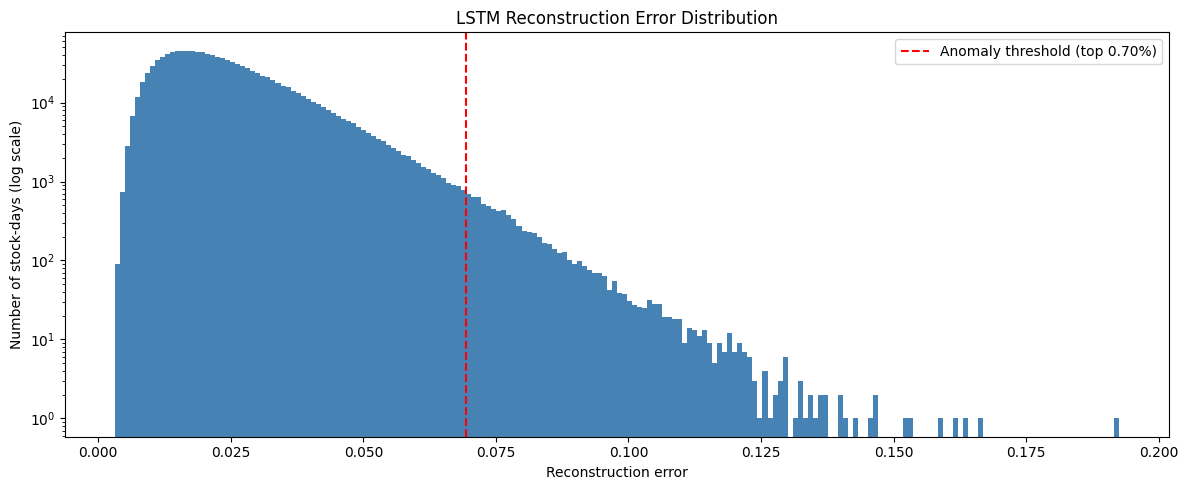

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(recon_errors_v2, bins=200, color="steelblue", edgecolor="none")
ax.axvline(threshold, color="red", linestyle="--", linewidth=1.5,
           label=f"Anomaly threshold (top 0.70%)")
ax.set_yscale("log")   # log scale so the small anomaly tail is visible
ax.set_title("LSTM Reconstruction Error Distribution")
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("Number of stock-days (log scale)")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("../results/lstm_error_distribution.png", dpi=150, bbox_inches="tight")

### How the Detector Separates Normal from Abnormal

Each stock-day gets a reconstruction error — how badly the model failed to copy it.
This chart shows the distribution of all ~1.17M errors (y-axis is log-scaled so the
rare high-error days are visible). The red line marks the threshold for the top
0.70% flagged as anomalies.

Most days sit in the tall bulk at low error — the model reconstructs them easily,
so they're "normal." A long thin tail stretches right: the rare days the model
*couldn't* reconstruct. Those are the anomalies, and the red line cuts them off.

**Takeaway:** the wide gap between the normal bulk and the anomaly tail is what
makes this a working detector. (The earlier undertrained model had no such gap —
its errors were all bunched together, which is why we retrained.)

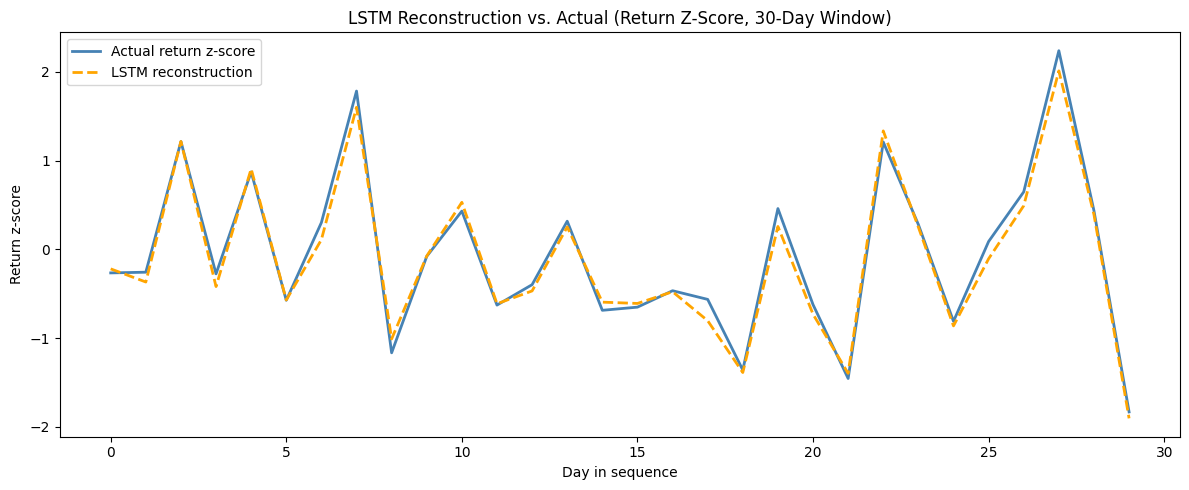

In [19]:
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_seq[:1], dtype=torch.float32).to(device)
    recon = model(sample).cpu().numpy()[0]
original = X_seq[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(original[:, 0], label="Actual return z-score", linewidth=2, color="steelblue")
ax.plot(recon[:, 0], label="LSTM reconstruction", linewidth=2, linestyle="--", color="orange")
ax.set_title("LSTM Reconstruction vs. Actual (Return Z-Score, 30-Day Window)")
ax.set_xlabel("Day in sequence")
ax.set_ylabel("Return z-score")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("../results/lstm_reconstruction_example.png", dpi=150, bbox_inches="tight")

### Does the Model Actually Work? Reconstruction vs. Reality

This chart tests whether the trained LSTM genuinely learned market behavior. The
blue line is a real 30-day return trajectory for one stock-day; the orange dashed
line is the model's reconstruction of it.

The two lines track each other almost perfectly — including the sharp spikes at
days 7, 22, and 27. This is the payoff of retraining: the earlier, undertrained
model flattened these spikes into a bland average, but the improved model (bigger
capacity, more training) reproduces them faithfully.

**Takeaway:** the model learned to copy normal market trajectories accurately.
That's exactly what we need — because a model that reconstructs normal well is a
model whose *failures* to reconstruct will pinpoint the abnormal.

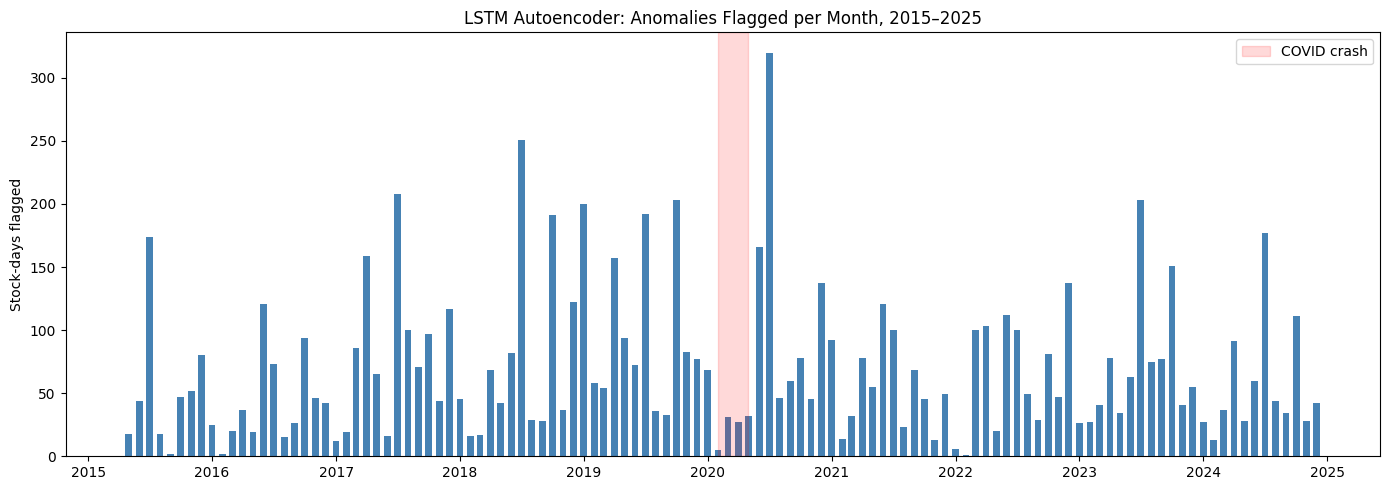

In [20]:
flagged = lstm_results[lstm_results["lstm_anomaly"]]
monthly = flagged.groupby(flagged.index.get_level_values("Date").to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.index, monthly.values, width=20, color="steelblue")
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           color="red", alpha=0.15, label="COVID crash")
ax.set_title("LSTM Autoencoder: Anomalies Flagged per Month, 2015–2025")
ax.set_ylabel("Stock-days flagged")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("../results/lstm_monthly_flags.png", dpi=150, bbox_inches="tight")

### LSTM Anomalies Over Time — An Unexpected Pattern

This shows how many days the LSTM flagged each month. The red band marks the 2020
COVID crash.

Unlike the Isolation Forest — which flagged the crash heavily — the LSTM barely
reacts to 2020; its flags are spread fairly evenly across the whole decade, and the
COVID months are actually below average. This makes the LSTM behave more like the
±3σ baseline than the Isolation Forest.

**Why:** the LSTM reads 30-day sequences and flags days that *break the recent
pattern*. During a sustained crisis, turbulence becomes the recent pattern, so a
volatile day stops looking like a departure — and the LSTM goes quiet, just as the
baseline did.

**Takeaway:** the LSTM appears to be a genuinely distinct third detector — it keys
on *departures from recent temporal patterns* rather than rarity of state (the
forest) or single-day return surprise (the baseline). The agreement analysis will
confirm how independent it truly is.

## Summary: Detector 3 (LSTM Autoencoder)

**Setup.** Trained an LSTM autoencoder on 2015–2019 (calm "normal" period), then
scored all stock-days 2015–2024 by reconstruction error. High error = the model
couldn't reproduce the trajectory = anomaly. Flagged the top 0.70% to match the
other two detectors.

**Model validation (diagnose-and-fix).** The first model (hidden size 32, 10
epochs) produced a weak signal — reconstruction errors bunched together (spread
ratio 2.8×), with the model flattening return spikes rather than capturing them.
Diagnosed as undertraining. Retrained with more capacity (hidden size 64) and more
epochs (40): final loss dropped 8× (0.20 → 0.024) and the anomaly spread ratio
tripled to 8.9×. Reconstruction inspection confirmed the improved model captures
return spikes it previously smoothed over.

**Key finding.** The LSTM does *not* behave like the Isolation Forest despite both
seeming volatility-related in early diagnostics. Its flags spread evenly across the
decade and it barely reacts to the 2020 crash — behaving more like the ±3σ baseline.
This suggests the LSTM detects *departures from recent temporal patterns*: during
sustained turbulence, turbulence becomes the expected pattern, so the LSTM stops
flagging (much as rolling normalization silenced the baseline in 2020).

**Implication.** All three detectors now appear to key on different things — return
surprise (±3σ), rarity of feature-space state (Isolation Forest), and temporal
pattern-break (LSTM). If confirmed in the agreement analysis, this means all three
are worth having, and the disagreements between them are the substance of the
research question.

In [21]:
# save charts already done via fig.savefig in each cell — verify they're in results/

# save the LSTM detector output (verdict + errors) for the agreement analysis
lstm_results.to_parquet(DATA_DIR / "detector3_lstm.parquet")

# save the improved model weights and errors (overwrite the weak v1)
torch.save(model.state_dict(), DATA_DIR / "lstm_autoencoder.pth")
np.save(DATA_DIR / "lstm_recon_errors.npy", recon_errors_v2)

print("Saved: detector3_lstm.parquet, lstm_autoencoder.pth, lstm_recon_errors.npy")
print("Charts in results/: lstm_reconstruction_example.png, lstm_error_distribution.png, lstm_monthly_flags.png")

Saved: detector3_lstm.parquet, lstm_autoencoder.pth, lstm_recon_errors.npy
Charts in results/: lstm_reconstruction_example.png, lstm_error_distribution.png, lstm_monthly_flags.png
